# RUN 15176

Let's look into trigger 2 data from one of the first HE runs.

In [2]:
import glob
import numpy as np
import pandas as pd
import tables as tb

import matplotlib.pyplot as plt

In [3]:
def plot_coord_info(df, run_number, c = ['X', 'Y', 'Z'], 
                    nbins = [60, 60, 60, 100], 
                    hist2d_range = ((-500, 500), (-500, 500)),
                    xlabels = ['X (mm)', 'Y (mm)', 'Z (mm)'], 
                    rad = 480, 
                    title = ''):
    plt.figure(figsize = (8, 6))
    plt.suptitle('Run {} - {} events \n'.format(run_number, len(df.event.unique())) + title)
    plt.subplot(2, 2, 1)
    plt.hist(df[c[0]], nbins[0])
    plt.xlabel(xlabels[0])
    plt.subplot(2, 2, 2)
    plt.hist(df[c[1]], nbins[1])
    plt.xlabel(xlabels[1])
    plt.subplot(2, 2, 3)
    plt.hist(df[c[2]], nbins[2])
    plt.xlabel(xlabels[2])
    plt.subplot(2, 2, 4)
    hist = plt.hist2d(df[c[0]], df[c[1]], bins=nbins[3], range = hist2d_range, cmap='viridis')
    plt.colorbar(hist[3], label='Counts')
    plt.gca().add_patch(plt.Circle((0, 0), rad, color='r', fill=False, linewidth=1)) 
    plt.xlabel(xlabels[0])
    plt.ylabel(xlabels[1])
    plt.tight_layout()

In [4]:
def plot_signal_info(df, run_number, nbins = (20, 100, 100, 100), plotval = [('nS1', 'nS2'), 'S2w', 'S2q', 'S2e'], xrange = [(0, 500), (0, 150000), (0, 500000)], title = ''):
    plt.figure(figsize = (8, 6))
    plt.suptitle('Run {} - {} events \n'.format(run_number, len(df.event.unique())) + title)
    plt.subplot(2, 2, 1)
    nsignal = df[['event', plotval[0][0], plotval[0][1]]].drop_duplicates()
    plt.hist(nsignal[plotval[0][0]], nbins[0], range=(0.5, nbins[0] + 0.5), histtype='step', label = 'nS1')
    plt.hist(nsignal[plotval[0][1]], nbins[0], range=(0.5, nbins[0] + 0.5), histtype='step', label = 'ns2')
    plt.legend()
    plt.xlabel('nS')

    plt.subplot(2, 2, 2)
    plt.hist(df[plotval[1]], nbins[1], xrange[0])
    plt.xlabel('S2 width')

    plt.subplot(2, 2, 3)
    plt.hist(df[plotval[2]], nbins[2], xrange[1])
    plt.xlabel('S2 charge')

    plt.subplot(2, 2, 4)
    plt.hist(df[plotval[3]], nbins[3], xrange[2])
    plt.xlabel('S2 energy')
    plt.yscale('log')

    plt.tight_layout()

In [5]:
def plot_generic_hist(df, var, run_n, nbins = None, range = None, yscale = 'linear', xlabel = '', title = ''):
    plt.hist(df[var], bins = nbins, range = range)
    plt.title('Run {} - {} events \n'.format(run_n, len(df.event.unique())) + title)
    plt.yscale(yscale)
    plt.xlabel(xlabel)

In [6]:
def plot_generic_scatter(df, xvar, yvar, run_n, lims = (None, None), alpha = 0.5, label = ['$\Delta$z (mm)', 'Ec (MeV)'], title = ''):
    plt.plot(df[xvar], df[yvar], '.', alpha = alpha)
    plt.xlim(lims[0])
    plt.ylim(lims[1])
    plt.title('Run {} - {} events \n'.format(run_n, len(df.event.unique())) + title)
    plt.xlabel(label[0])
    plt.ylabel(label[1])
    plt.grid()

In [7]:
def hist2d_plot(df, xvar, yvar, nbins = 100, range = (None, None), label = [r'DT ($\mu$s)', 'S2 energy (pes)']):
    hist = plt.hist2d(df[xvar], df[yvar], bins = nbins, range = (range[0], range[1]), cmap='viridis')
    plt.colorbar(hist[3], label='Counts')

    plt.xlabel(label[0])
    plt.ylabel(label[1])

In [8]:
from invisible_cities.core.fit_functions import expo
from invisible_cities.core.fit_functions import profileX
from scipy.optimize                      import curve_fit

def plot_profile(df, xvar, yvar, std = False, fitbins = 20, plotbins = 50, plotrange = (None, None), axlabel = ['', '']):
    x, y, sy = profileX(df[xvar], df[yvar], std=std, nbins = fitbins)
    # par, err  = curve_fit(fitfun, x, y, sigma=sy, p0 = initial_values)
    plt.errorbar(x = x, y = y, yerr = sy, fmt = 'r.')
    # plt.plot(x, fitfun(y, *par), 'r-', label = 'write here variable')
    plt.hist2d(df[xvar], df[yvar], bins = plotbins, range = plotrange)
    plt.xlabel(axlabel[0])
    plt.ylabel(axlabel[1])

In [9]:
from scipy.optimize import curve_fit
from scipy.integrate import quad

def gauss(x, a, mu, sigma):
    return a * np.exp(-((x - mu) / sigma) ** 2 / 2)

def expon(x, m, c):
    return m *np.exp(-x/c)

def peak_fit(x, a, mu, sigma, m, c):
    return gauss(x, a, mu, sigma) + expon(x, m, c)

#trashy function, very hard coded
def fit_and_plot_peaks_resolution(data, fun, nbins, plotrange, fitrange, initial_params, bounds, title, density = True):
    y, x = np.histogram(data, nbins, range = plotrange, density = density)
    # from the xbins we select the range to plot, otherwise things don't match
    fit_mask = (x > fitrange[0]) & (x < fitrange[1])
    fit_x, fit_y = x[fit_mask], y[fit_mask[:-1]]
    params, cov = curve_fit(fun, fit_x, fit_y, p0=initial_params, bounds = bounds, maxfev = 2000)
    a, mu, sigma, m, c = params[0], params[1], params[2], params[3], params[4]
    yfit = fun(fit_x, a, mu, sigma, m, c)

    R = 2 * np.sqrt(2 * np.log(2)) * sigma * 100 / mu
    sR = R * np.sqrt((cov[2, 2] / sigma) **2 + (cov[1, 1]/mu)**2)

    legend_string = r'$\mu={:.3f} \pm {:.3e}$'.format(mu, cov[1,1]) + '\n' + \
                    r'$\sigma={:.3f} \pm {:.3e}$'.format(sigma, cov[2,2]) + '\n' + \
                    r'R(%) = ${:.3f} \pm {:.3e}$'.format(R, sR)
    plt.hist(data, nbins, range = plotrange, histtype='step', density = density)
    plt.plot(fit_x, yfit, 'r-', label = legend_string)
    plt.legend()
    plt.xlabel('E (MeV)')
    if density:
        plt.ylabel('Probability density (1 / MeV)')
    else:
        plt.ylabel('Events')
    plt.title(title)
    plt.grid()
    plt.show()
    return params, R

PROBAR A:

* Hacer primero un corte en las energías del S2 asegurando quitar el Kr, así tendré más estadística porque no voy a quitar eventos en los que haya algún pico de otras cositas
* Luego ya puedo ir mirando otras cosas etc...


Parece que la correspondencia entre dst y reco no está clarineta, le queda el indice a reco de los pmaps. En general parece que si hay 1S1 es directo, es correspondencia uno a uno, pero si hay más de 1S1, hay correspondencia por grupos de S1 (es decir, cada S1 se junta con un S2 y da por norma general cosas muy similares a los npeak de reco... A no ser que haya algun S1 bastante sepadado supongo)

In [26]:
run_number = 15176
run_time = 86544 / 3600

path = '/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT100/data/runs/{run_number}/'.format(run_number = run_number)

data_path = path + '*/*'
save_path = path + 'all_info.h5' #'dst.h5'
save_path_clean = path + 'all_info_clean.h5' #'all_info.h5' #'dst.h5'
save_path_summary = path + 'all_info_summary_new.h5' # NO ACABÓ DE PROCESAR BIEN...

files = sorted(glob.glob(data_path + '*'), key=lambda x: (x.split('/')[-2], int(x.split('/')[-1].split('_')[2])))

In [27]:
dst = pd.read_hdf(save_path_summary, 'DST/Events')
reco_summ = pd.read_hdf(save_path_summary, 'RECO/Events_summary')

## DST info

##### All events

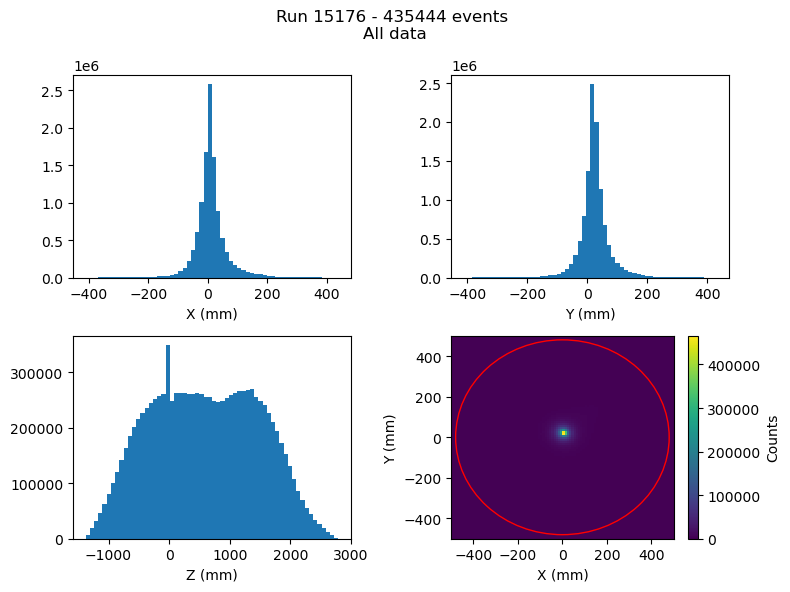

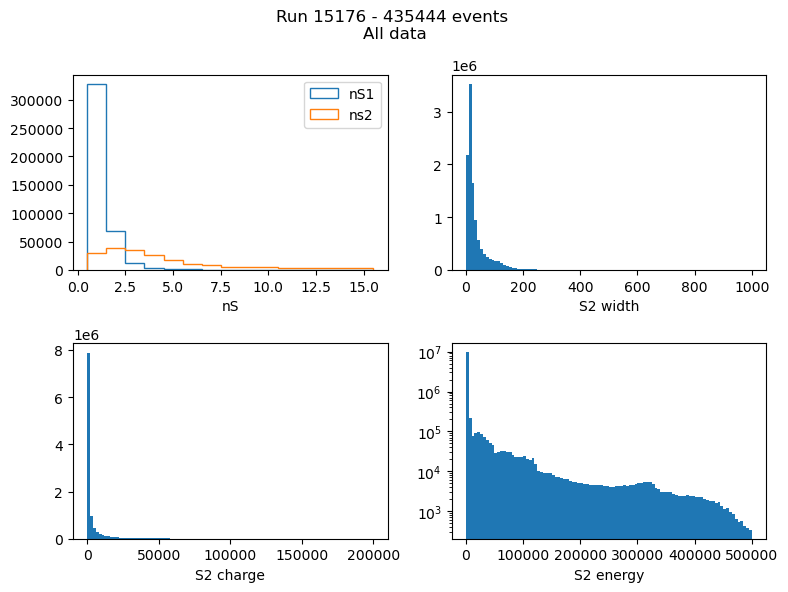

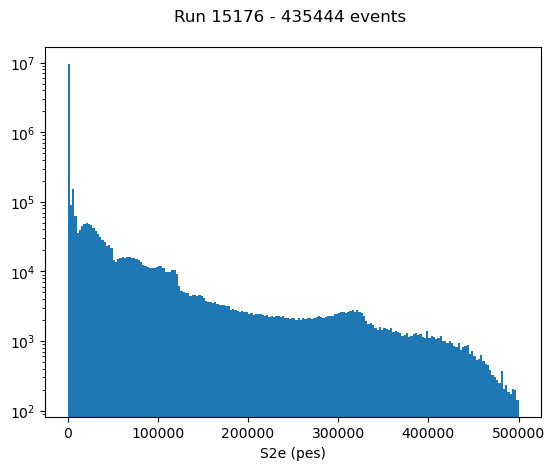

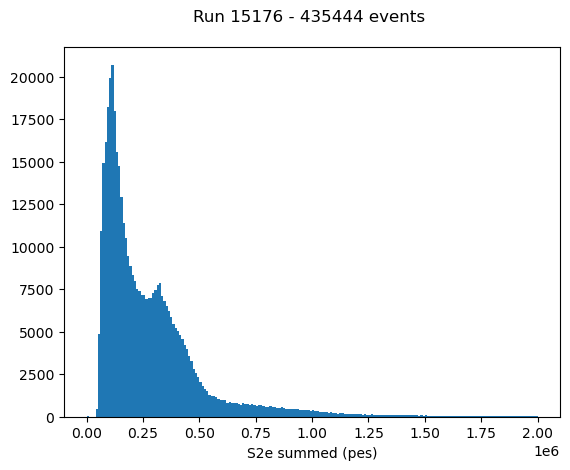

In [28]:
plot_coord_info (dst, run_number, title = 'All data')
plt.show()
plot_signal_info(dst, run_number, title = 'All data', nbins = (15,100,100,100),  xrange = [(0, 1000), (0, 200000), (0, 500000)])
plt.show()
plot_generic_hist(dst, 'S2e', run_number, nbins = 200, range = (0, 500000), xlabel = 'S2e (pes)', yscale = 'log')
plt.show()
plot_generic_hist(dst.groupby('event').sum().reset_index(), 'S2e', run_number, nbins = 200, range = (0, 2000000), xlabel = 'S2e summed (pes)', yscale = 'linear')
plt.show()

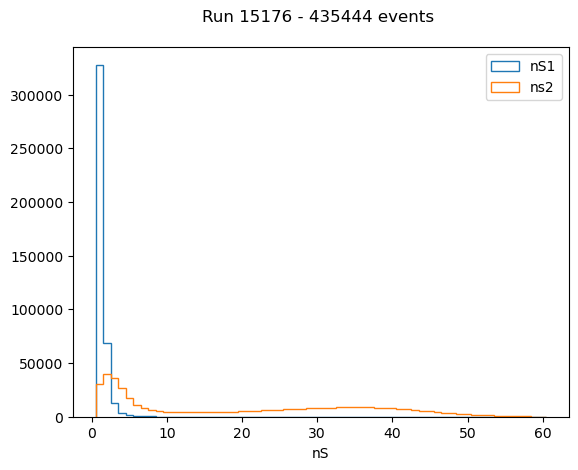

In [29]:
nbins = [60]
nsignal = dst[['event', 'nS1', 'nS2']].drop_duplicates()
plt.hist(nsignal.nS1, nbins[0], range=(0.5, nbins[0] + 0.5), histtype='step', label = 'nS1')
plt.hist(nsignal.nS2, nbins[0], range=(0.5, nbins[0] + 0.5), histtype='step', label = 'ns2')
plt.title('Run {} - {} events \n'.format(run_number, len(dst.event.unique())))
plt.legend()
plt.xlabel('nS')
plt.show()

##### DT inside the chamber

In [30]:
min_dt, max_dt = 0, 1500

In [31]:
dt_dst = dst[(dst.DT > min_dt) & (dst.DT < max_dt)].copy()

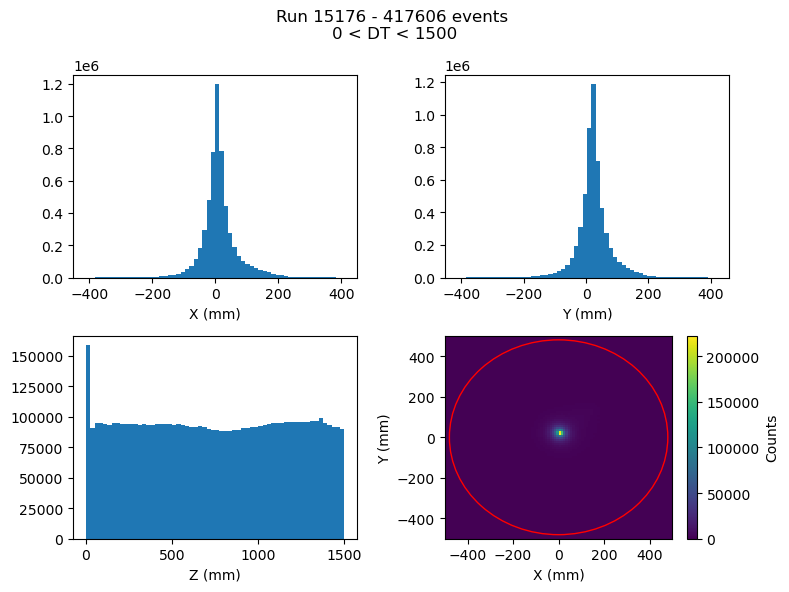

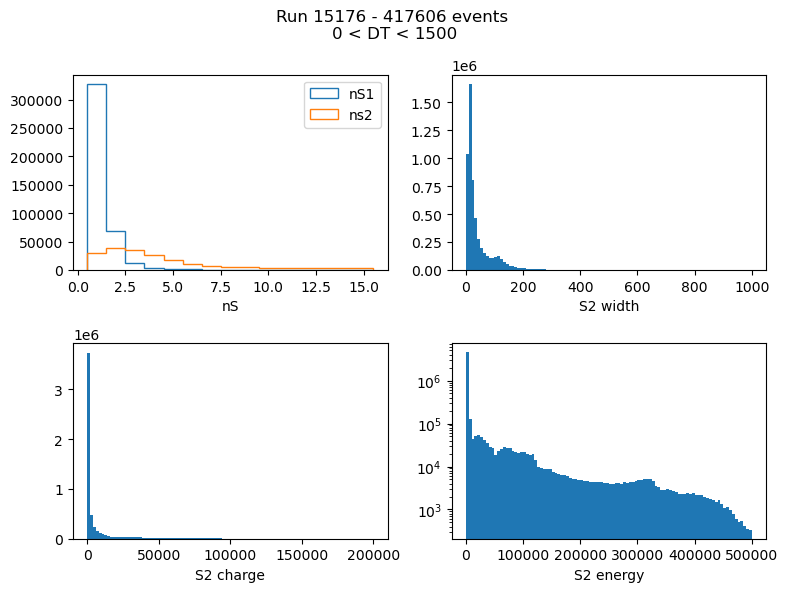

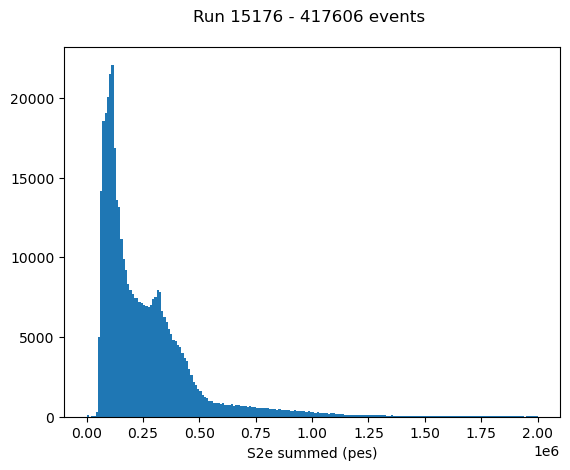

In [32]:
plot_coord_info (dt_dst, run_number, title = '0 < DT < 1500')
plt.show()
plot_signal_info(dt_dst, run_number, title = '0 < DT < 1500', nbins = (15,100,100,100),  xrange = [(0, 1000), (0, 200000), (0, 500000)])
plt.show()
plot_generic_hist(dt_dst.groupby('event').sum().reset_index(), 'S2e', run_number, nbins = 200, range = (0, 2000000), xlabel = 'S2e summed (pes)', yscale = 'linear')
plt.show()

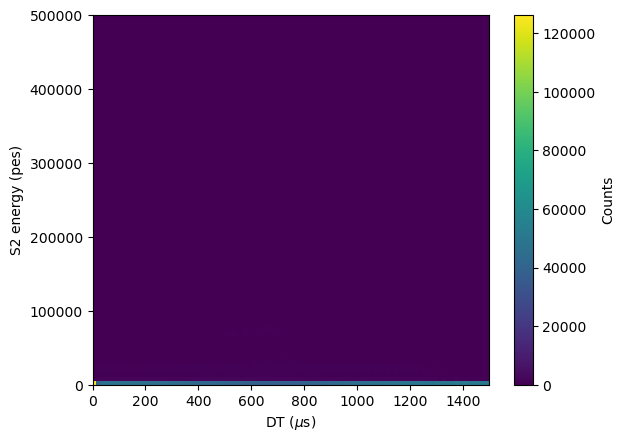

In [33]:
hist2d_plot(dt_dst, 'DT', 'S2e', nbins = 100, range = ((0, 1500), (0, 500000)), label = ['DT ($\mu$s)', 'S2 energy (pes)'])

##### S2 energy cut for the peaks

We see that a lot of the peaks have energy below 10k pes (Kr and x-rays), so we clean on that!

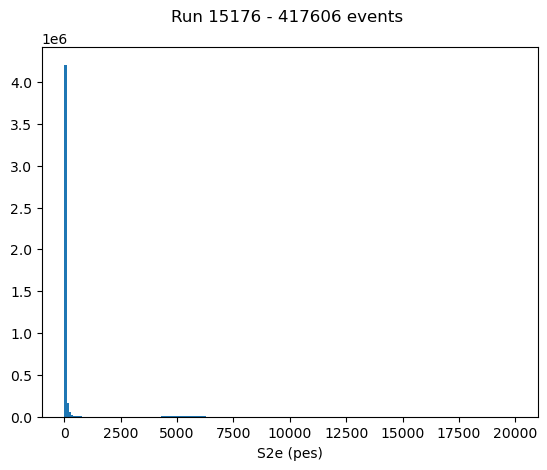

In [34]:
plot_generic_hist(dt_dst, 'S2e', run_number, nbins = 200, range = (0, 20000), xlabel = 'S2e (pes)', yscale = 'linear')
plt.show()

In [35]:
s2e_peak_cut = 10000

In [36]:
s2e_peak_dst = dt_dst[dt_dst.S2e > s2e_peak_cut]

In [37]:
# Re-count the number of S1 and S2
s2e_peak_dst = s2e_peak_dst.merge(s2e_peak_dst.groupby('event').agg(ns1 = ('s1_peak', lambda x: x.nunique()), 
                                                                    ns2 = ('s2_peak', lambda x: x.nunique())).reset_index(), how ='left')

In [38]:
len(s2e_peak_dst.event.unique()) / len(dt_dst.event.unique())

0.9997701182454275

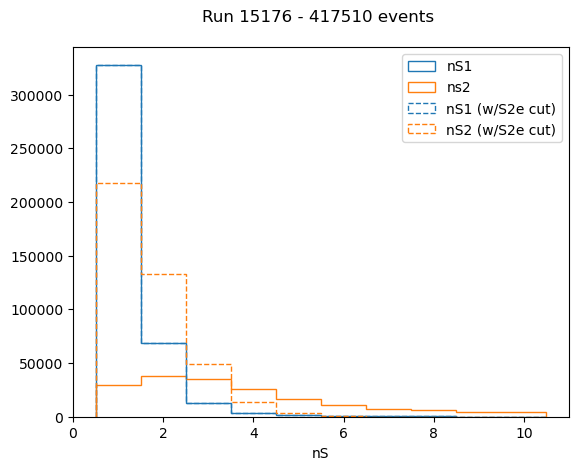

In [39]:
nbins = [10]
nsignal = s2e_peak_dst[['event', 'nS1', 'nS2', 'ns1', 'ns2']].drop_duplicates()
plt.hist(nsignal.nS1, nbins[0], range=(0.5, nbins[0] + 0.5), color = 'tab:blue', histtype='step', label = 'nS1')
plt.hist(nsignal.nS2, nbins[0], range=(0.5, nbins[0] + 0.5), color = 'tab:orange', histtype='step', label = 'ns2')

plt.hist(nsignal.ns1, nbins[0], range=(0.5, nbins[0] + 0.5), color = 'tab:blue', ls = '--', histtype='step', label  = 'nS1 (w/S2e cut)')
plt.hist(nsignal.ns2, nbins[0], range=(0.5, nbins[0] + 0.5), color = 'tab:orange', ls = '--', histtype='step', label = 'nS2 (w/S2e cut)')
plt.title('Run {} - {} events \n'.format(run_number, len(s2e_peak_dst.event.unique())))
plt.legend()
# plt.yscale('log')
plt.xlabel('nS')
plt.show()

##### 1S1

In [40]:
ones1_dst = dt_dst[(dt_dst.nS1 == 1)]

ones1_s2e_dst = s2e_peak_dst[(s2e_peak_dst.ns1 == 1)]

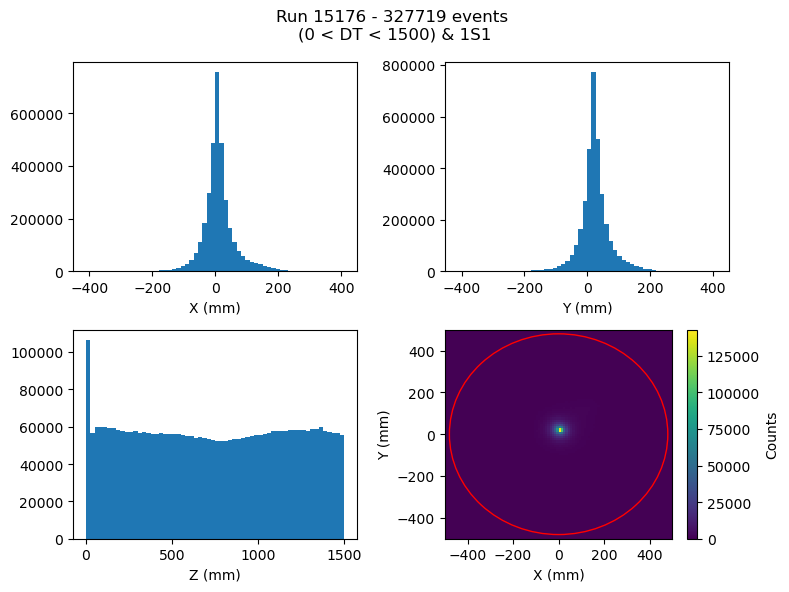

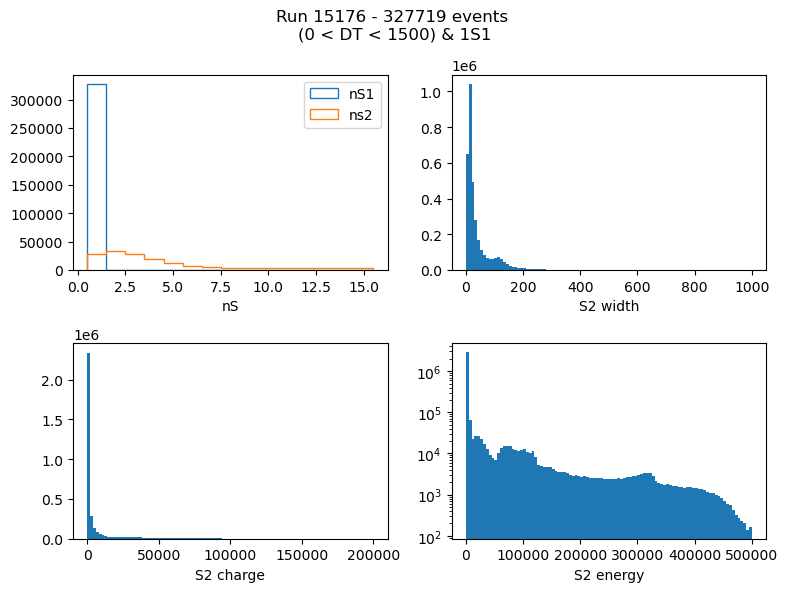

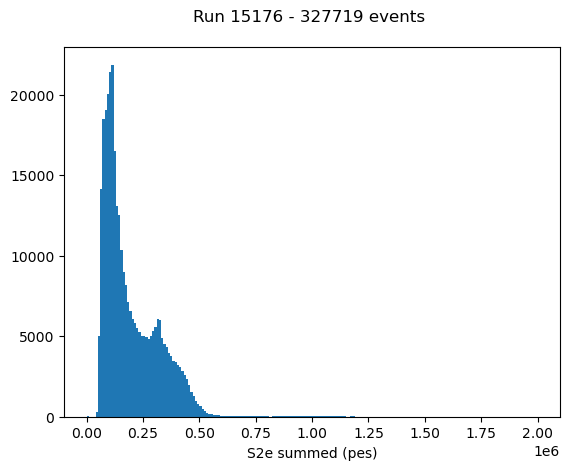

In [41]:
plot_coord_info (ones1_dst, run_number, title = '(0 < DT < 1500) & 1S1')
plt.show()
plot_signal_info(ones1_dst, run_number, title = '(0 < DT < 1500) & 1S1', nbins = (15,100,100,100),  xrange = [(0, 1000), (0, 200000), (0, 500000)])
plt.show()
plot_generic_hist(ones1_dst.groupby('event').sum().reset_index(), 'S2e', run_number, nbins = 200, range = (0, 2000000), xlabel = 'S2e summed (pes)', yscale = 'linear')
plt.show()

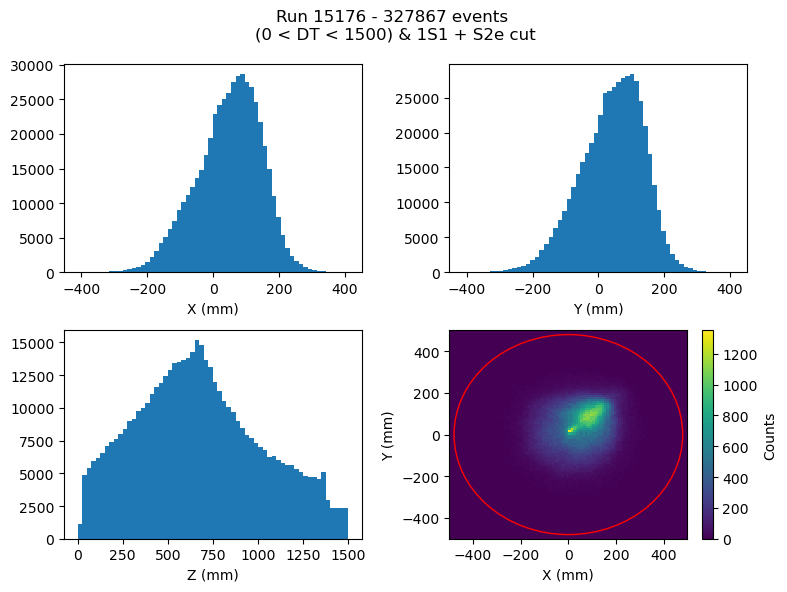

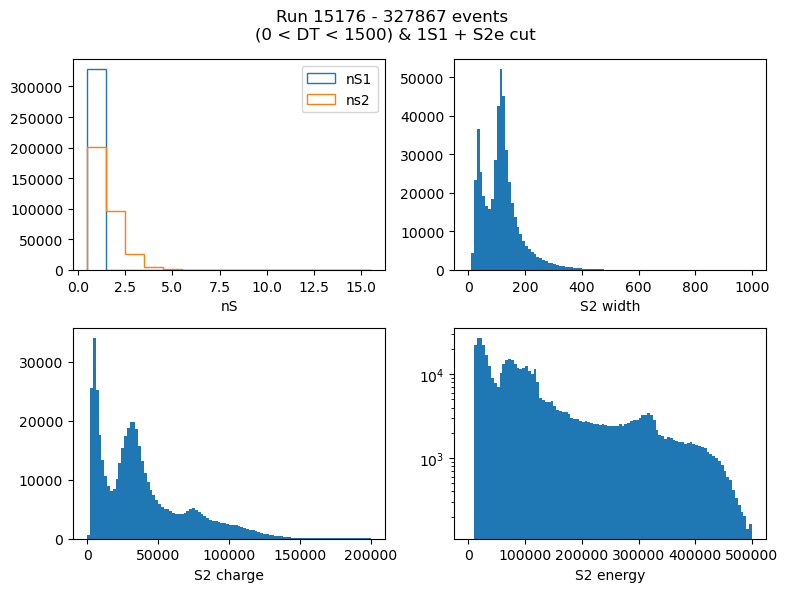

In [42]:
plot_coord_info (ones1_s2e_dst, run_number, title = '(0 < DT < 1500) & 1S1 + S2e cut')
plt.show()
plot_signal_info(ones1_s2e_dst, run_number, title = '(0 < DT < 1500) & 1S1 + S2e cut', nbins = (15,100,100,100), plotval = [('ns1', 'ns2'), 'S2w', 'S2q', 'S2e'],  xrange = [(0, 1000), (0, 200000), (0, 500000)])
plt.show()

##### 1S2

In [43]:
ones2_dst = ones1_dst[(ones1_dst.nS2 == 1)]

ones2_s2e_dst = ones1_s2e_dst[(ones1_s2e_dst.ns2 == 1)]

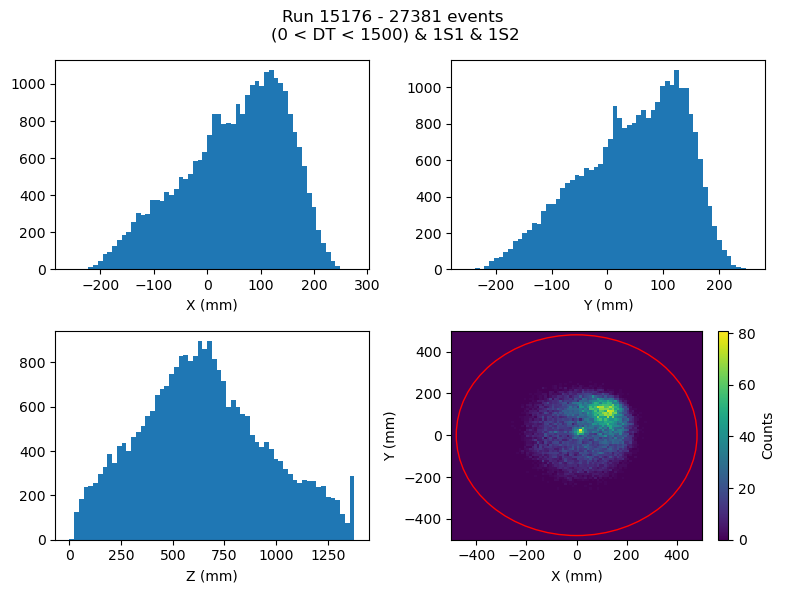

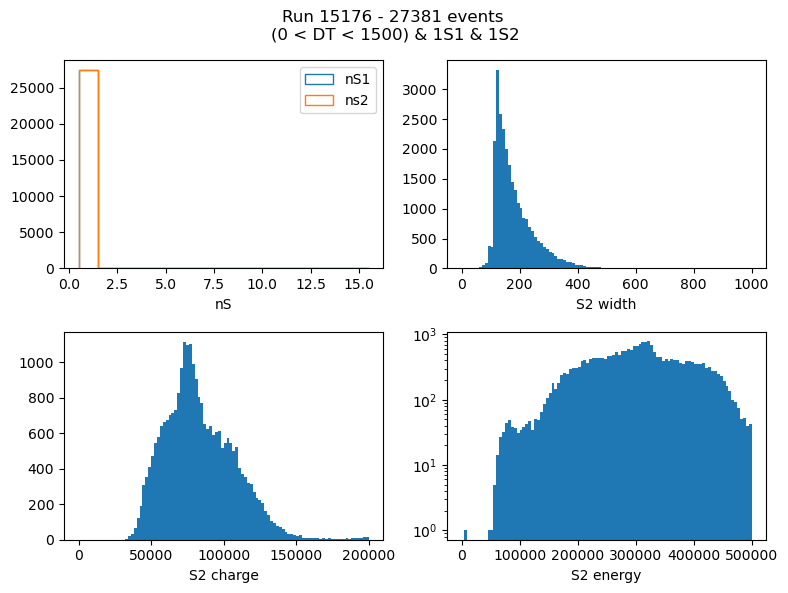

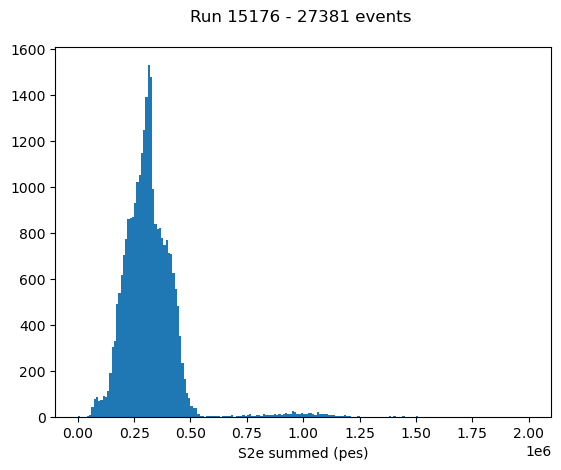

In [44]:
plot_coord_info (ones2_dst, run_number, title = '(0 < DT < 1500) & 1S1 & 1S2')
plt.show()
plot_signal_info(ones2_dst, run_number, title = '(0 < DT < 1500) & 1S1 & 1S2', nbins = (15,100,100,100),  xrange = [(0, 1000), (0, 200000), (0, 500000)])
plt.show()
plot_generic_hist(ones2_dst.groupby('event').sum().reset_index(), 'S2e', run_number, nbins = 200, range = (0, 2000000), xlabel = 'S2e summed (pes)', yscale = 'linear')
plt.show()

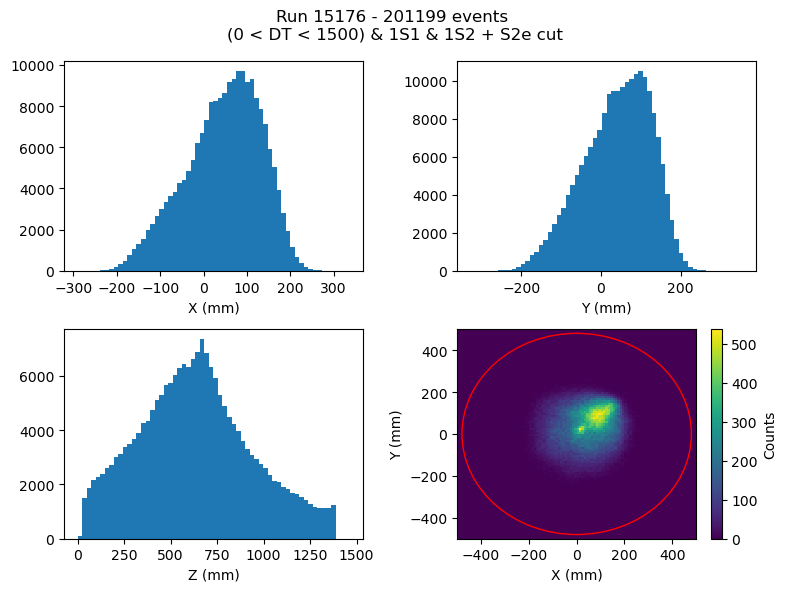

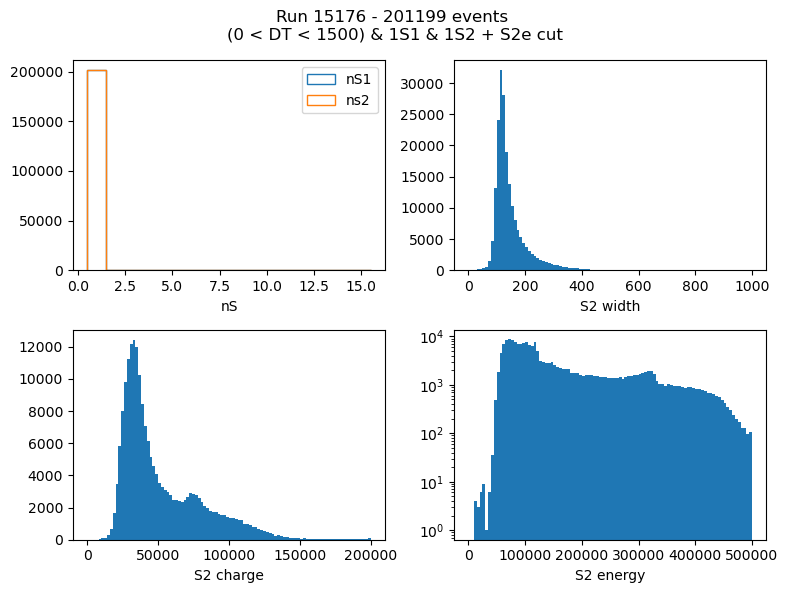

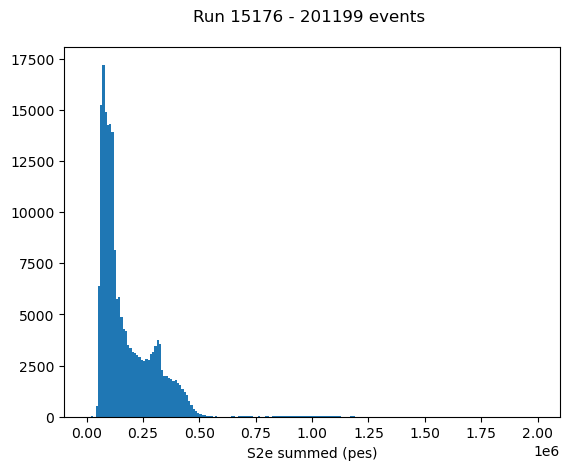

In [45]:
plot_coord_info (ones2_s2e_dst, run_number, title = '(0 < DT < 1500) & 1S1 & 1S2 + S2e cut')
plt.show()
plot_signal_info(ones2_s2e_dst, run_number, title = '(0 < DT < 1500) & 1S1 & 1S2 + S2e cut', nbins = (15,100,100,100), plotval = [('ns1', 'ns2'), 'S2w', 'S2q', 'S2e'], xrange = [(0, 1000), (0, 200000), (0, 500000)])
plt.show()
plot_generic_hist(ones2_s2e_dst.groupby('event').sum().reset_index(), 'S2e', run_number, nbins = 200, range = (0, 2000000), xlabel = 'S2e summed (pes)', yscale = 'linear')
plt.show()

##### S2 energy (for DS peak)

In [46]:
min_s2e, max_s2e = 200000, 400000
s2e_dst = ones2_dst[(ones2_dst.S2e > min_s2e) & (ones2_dst.S2e < max_s2e)]

s2e_dst_new = ones2_s2e_dst[(ones2_s2e_dst.S2e > min_s2e) & (ones2_s2e_dst.S2e < max_s2e)]

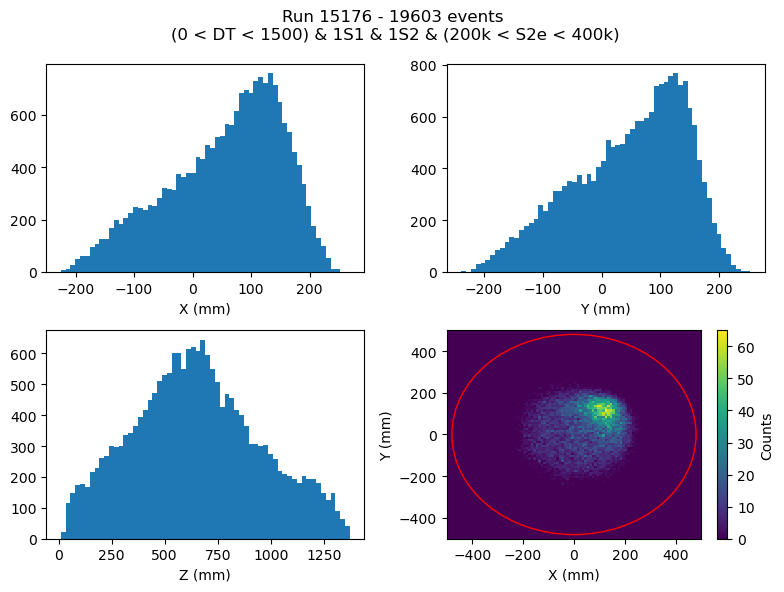

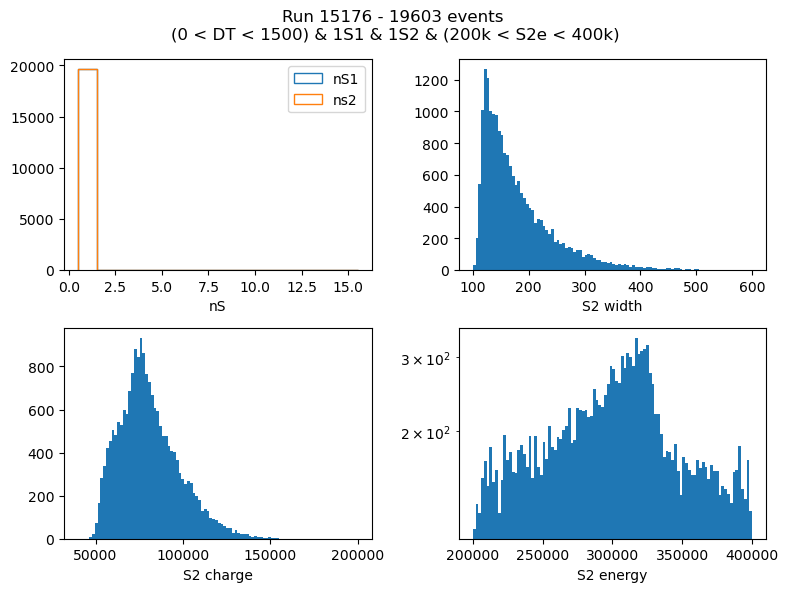

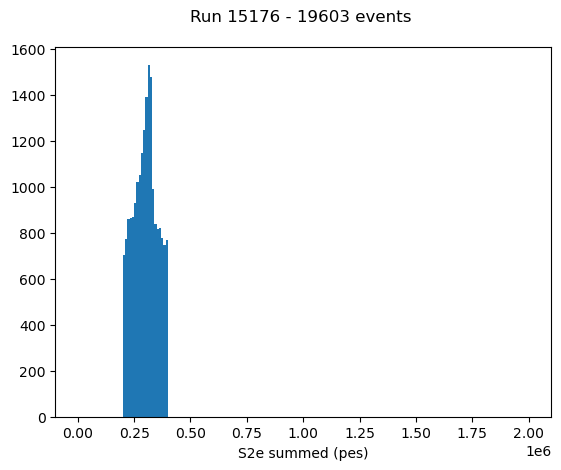

In [47]:
plot_coord_info (s2e_dst, run_number, title = '(0 < DT < 1500) & 1S1 & 1S2 & (200k < S2e < 400k)')
plt.show()
plot_signal_info(s2e_dst, run_number, title = '(0 < DT < 1500) & 1S1 & 1S2 & (200k < S2e < 400k)', nbins = (15,100,100,100),  xrange = [(100, 600), (40000, 200000), (min_s2e, max_s2e)])
plt.show()
plot_generic_hist(s2e_dst.groupby('event').sum().reset_index(), 'S2e', run_number, nbins = 200, range = (0, 2000000), xlabel = 'S2e summed (pes)', yscale = 'linear')
plt.show()

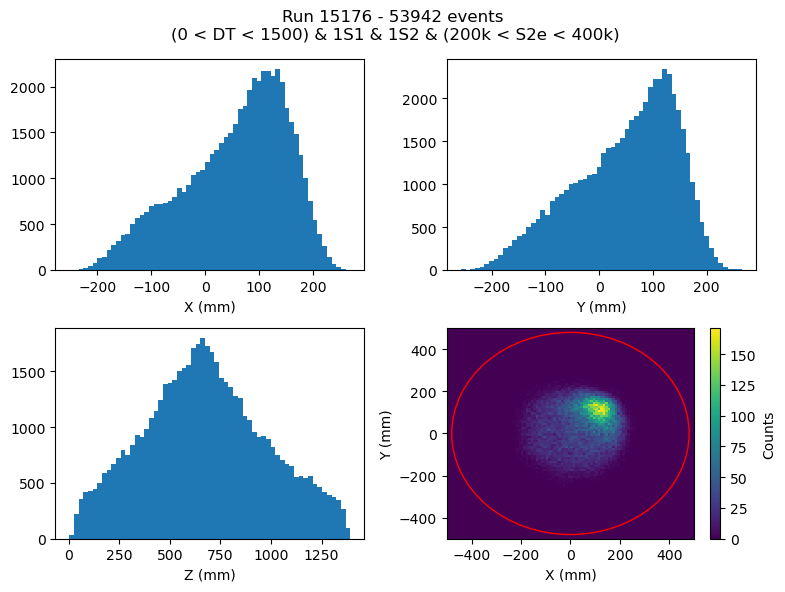

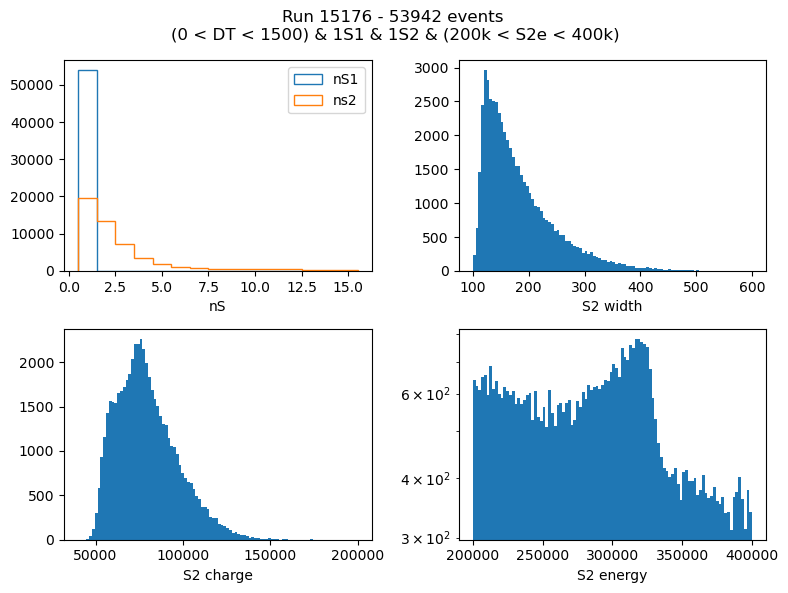

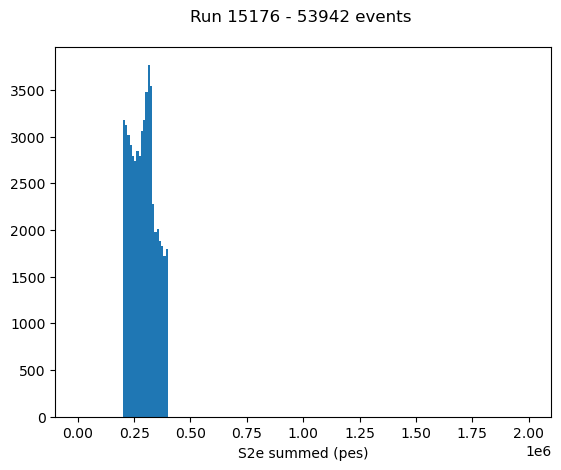

In [48]:
plot_coord_info (s2e_dst_new, run_number, title = '(0 < DT < 1500) & 1S1 & 1S2 & (200k < S2e < 400k)')
plt.show()
plot_signal_info(s2e_dst_new, run_number, title = '(0 < DT < 1500) & 1S1 & 1S2 & (200k < S2e < 400k)', nbins = (15,100,100,100),  xrange = [(100, 600), (40000, 200000), (min_s2e, max_s2e)])
plt.show()
plot_generic_hist(s2e_dst_new.groupby('event').sum().reset_index(), 'S2e', run_number, nbins = 200, range = (0, 2000000), xlabel = 'S2e summed (pes)', yscale = 'linear')
plt.show()

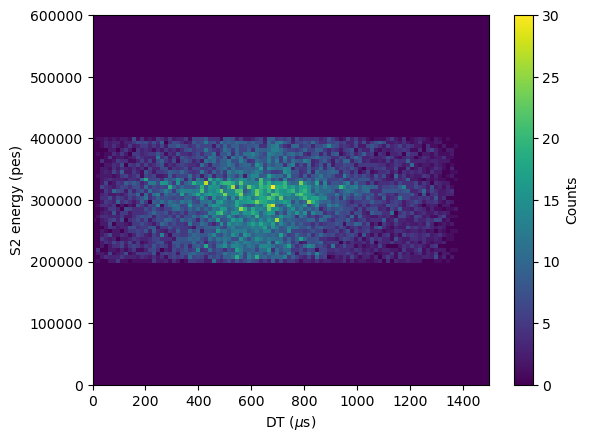

In [49]:
hist2d_plot(s2e_dst, 'DT', 'S2e', nbins = 100, range = ((0, 1500), (0, 600000)), label = ['DT ($\mu$s)', 'S2 energy (pes)'])

In [50]:
ones1_dst=ones1_dst.merge(ones1_dst.groupby('event').sum().S2e.rename('S2e_total'), on='event')
ones1_s2e_dst = ones1_dst[(ones1_dst.S2e_total > min_s2e) & (ones1_dst.S2e_total < max_s2e)]

In [51]:
print('DT  cut eff: {}'.format(len(dt_dst.event.unique()) / len(dst.event.unique())))
print('1S1 cut eff: {}'.format(len(ones1_dst.event.unique()) / len(dst.event.unique())))
print('1S1 + S2e cut eff: {}'.format(len(ones1_s2e_dst.event.unique()) / len(dst.event.unique())))
print('1S2 cut eff: {}'.format(len(ones2_dst.event.unique()) / len(dst.event.unique())))
print('S2e cut eff: {}'.format(len(s2e_dst.event.unique()) / len(dst.event.unique())))

print('RATE: {}'.format(len(s2e_dst.event.unique()) /(run_time * 3600 * len(dst.event.unique()))))

DT  cut eff: 0.9590349160856505
1S1 cut eff: 0.752608831445605
1S1 + S2e cut eff: 0.2271865038902821
1S2 cut eff: 0.06288064596136357
S2e cut eff: 0.04501841798256492
RATE: 5.201795385302842e-07


In [52]:
# hits2d Z vs Zrms**2 ?

## Summary info from hits

##### All data

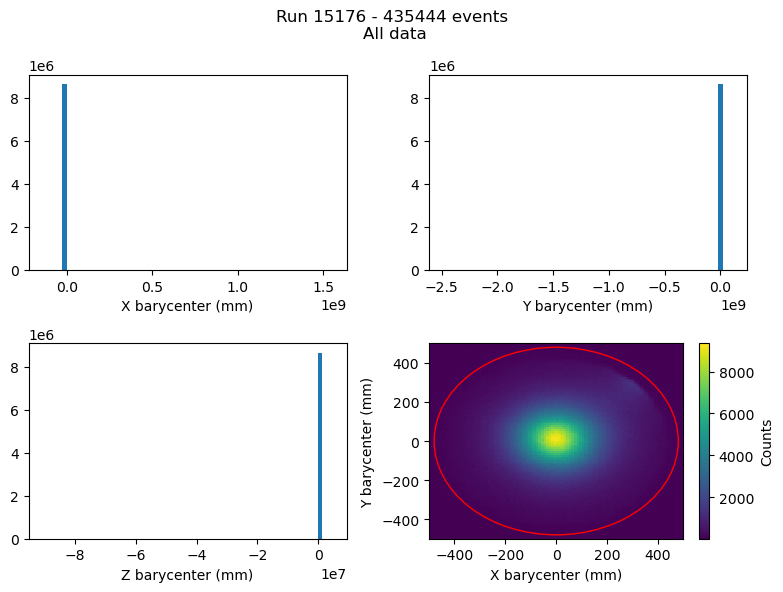

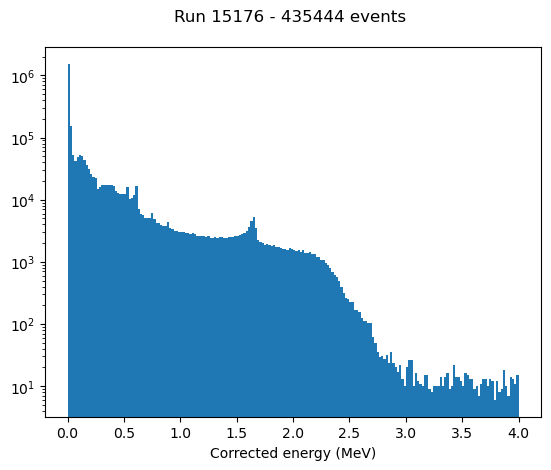

In [53]:
plot_coord_info (reco_summ, run_number, c = ['X_bary', 'Y_bary', 'Z_bary'], title = 'All data', xlabels = ['X barycenter (mm)', 'Y barycenter (mm)', 'Z barycenter (mm)'])
plt.show()
plot_generic_hist(reco_summ, 'total_energy', run_number, nbins = 200, range = (0, 4), xlabel = 'Corrected energy (MeV)', yscale = 'log')
plt.show()

In [54]:
run_time

24.04

##### Z barycenter

In [55]:
dt_reco_summ = reco_summ[(reco_summ.Z_bary > min_dt) & (reco_summ.Z_bary < max_dt)].copy()

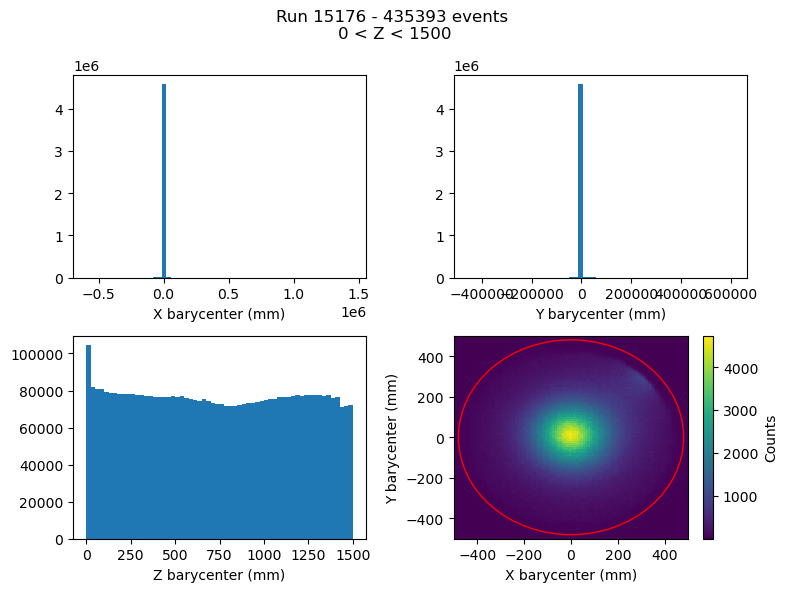

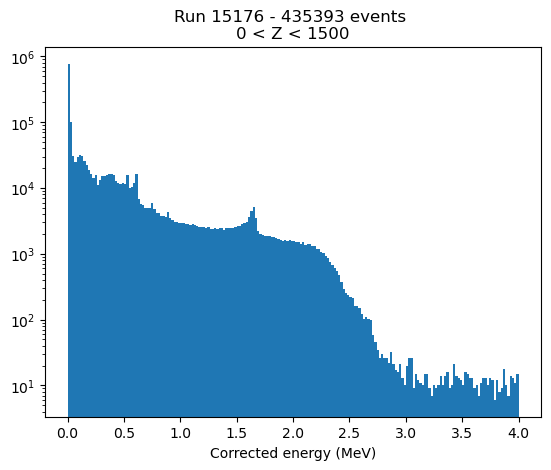

In [56]:
plot_coord_info (dt_reco_summ, run_number, c = ['X_bary', 'Y_bary', 'Z_bary'], title = '0 < Z < 1500', xlabels = ['X barycenter (mm)', 'Y barycenter (mm)', 'Z barycenter (mm)'])
plt.show()
plot_generic_hist(dt_reco_summ, 'total_energy', run_number, nbins = 200, range = (0, 4), xlabel = 'Corrected energy (MeV)', title = '0 < Z < 1500', yscale = 'log')
plt.show()

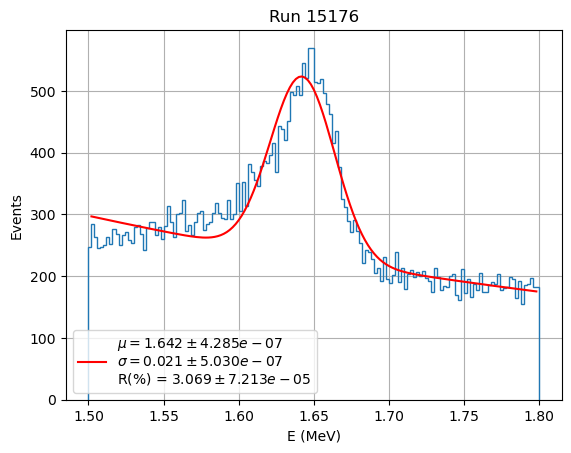

In [57]:
rang = (1.5, 1.8)
initial_params = [250, 1.65, 0.02, 1, 7]
bounds = ([0, 0, 0, -np.inf, 0], [np.inf, np.inf, np.inf, np.inf, np.inf])

r = fit_and_plot_peaks_resolution(dt_reco_summ.total_energy, peak_fit, 150, rang, rang, initial_params, bounds, 'Run {}'.format(run_number), density = False)

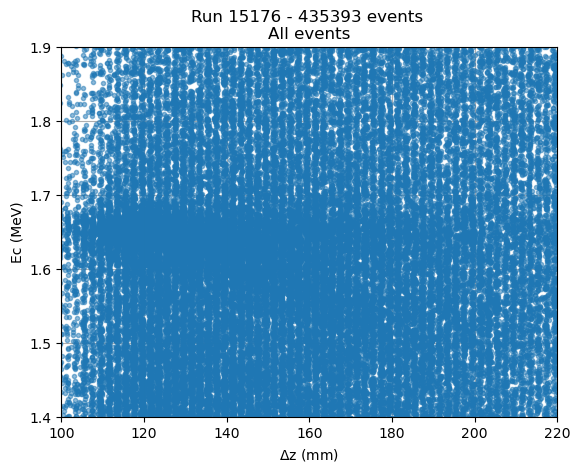

In [58]:
plot_generic_scatter(dt_reco_summ, 'dZ', 'total_energy', run_number, lims = ((100, 220), (1.4, 1.9)), alpha = 0.5, label = ['$\Delta$z (mm)', 'Ec (MeV)'], title = 'All events')

### Now if we clean using the DST cuts applied before:

In [59]:
cut_dst_events = s2e_dst.event.unique()

final_reco_summ = dt_reco_summ[np.isin(dt_reco_summ.event, cut_dst_events)]

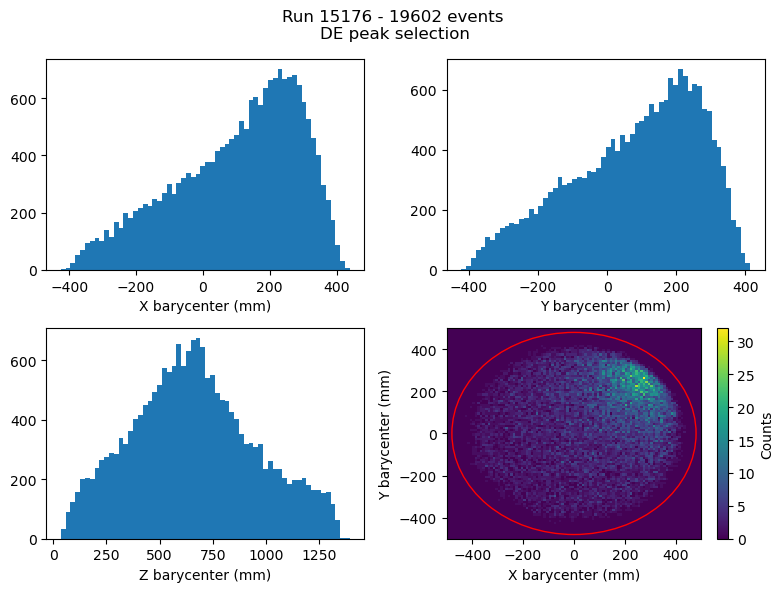

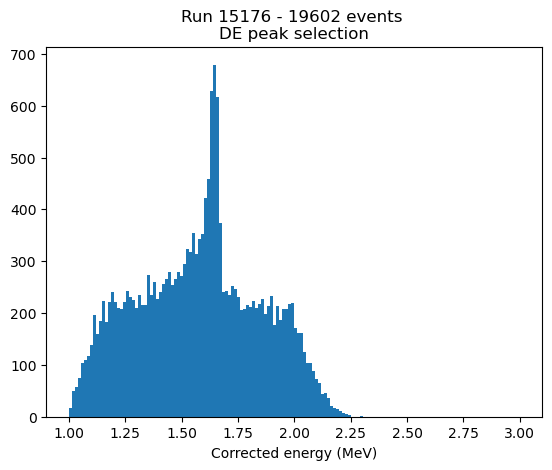

In [60]:
plot_coord_info (final_reco_summ, run_number, c = ['X_bary', 'Y_bary', 'Z_bary'], title = 'DE peak selection', xlabels = ['X barycenter (mm)', 'Y barycenter (mm)', 'Z barycenter (mm)'])
plt.show()
plot_generic_hist(final_reco_summ, 'total_energy', run_number, nbins = 150, range = (1, 3), xlabel = 'Corrected energy (MeV)', title = 'DE peak selection')
plt.show()

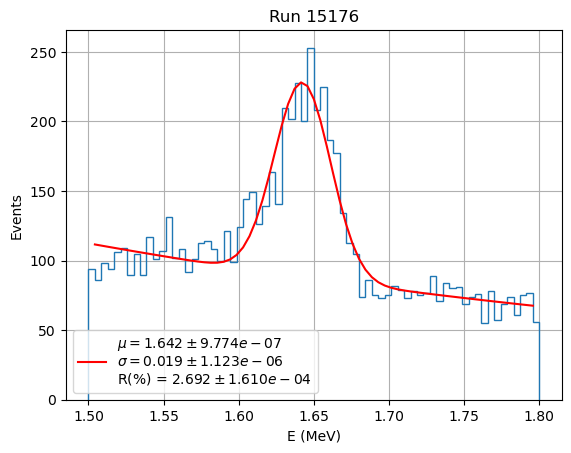

In [61]:
rang = (1.5, 1.8)
initial_params = [250, 1.65, 0.02, 1, 7]
bounds = ([0, 0, 0, -np.inf, 0], [np.inf, np.inf, np.inf, np.inf, np.inf])

r = fit_and_plot_peaks_resolution(final_reco_summ.total_energy, peak_fit, 70, rang, rang, initial_params, bounds, 'Run {}'.format(run_number), density = False)

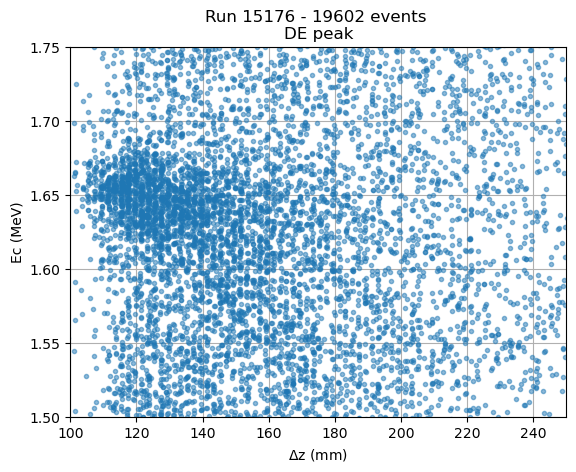

In [62]:
plot_generic_scatter(final_reco_summ, 'dZ', 'total_energy', run_number, lims = ((100, 250), (1.5, 1.75)), alpha = 0.5, label = ['$\Delta$z (mm)', 'Ec (MeV)'], title = 'DE peak')

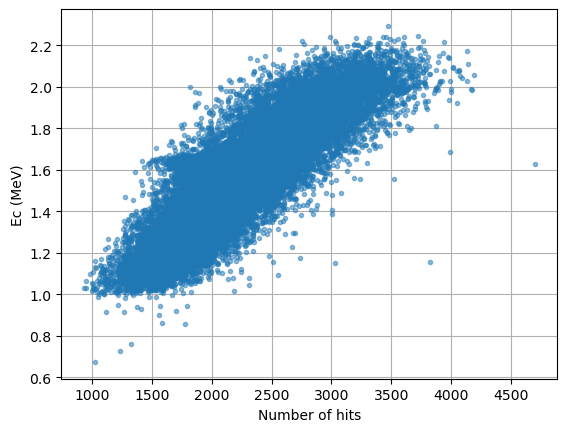

In [63]:
plt.plot(final_reco_summ.num_hits, final_reco_summ.total_energy, '.', alpha = 0.5)
# plt.xlim((100, 250))
# plt.ylim((1.25, 2))
plt.xlabel('Number of hits')
plt.ylabel('Ec (MeV)')
plt.grid()

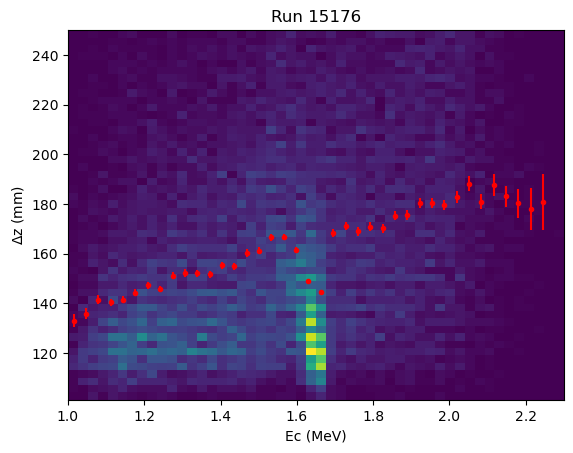

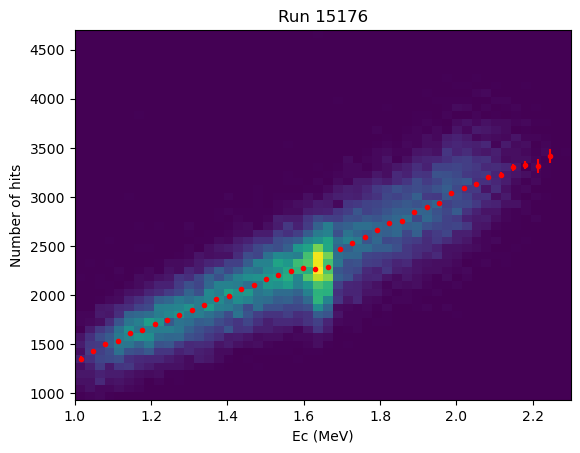

In [64]:
dz_mask = (final_reco_summ.dZ > 100) & (final_reco_summ.dZ < 250) 

plot_profile(final_reco_summ[dz_mask], 'total_energy', 'dZ', fitbins = 50, plotbins = 50,plotrange=((1, 2.3), None), axlabel = ['Ec (MeV)', '$\Delta$z (mm)'])
plt.title('Run {}'.format(run_number))
plt.show()
plot_profile(final_reco_summ, 'total_energy', 'num_hits', fitbins = 50, plotbins = 50, plotrange=((1, 2.3), None), axlabel = ['Ec (MeV)', 'Number of hits'])
plt.title('Run {}'.format(run_number))
plt.show()

In [65]:
final_reco_summ['rad'] = np.sqrt(final_reco_summ.X_bary **2 + final_reco_summ.Y_bary ** 2)

/scratch/11644740/ipykernel_2640624/2631268149.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_reco_summ['rad'] = np.sqrt(final_reco_summ.X_bary **2 + final_reco_summ.Y_bary ** 2)


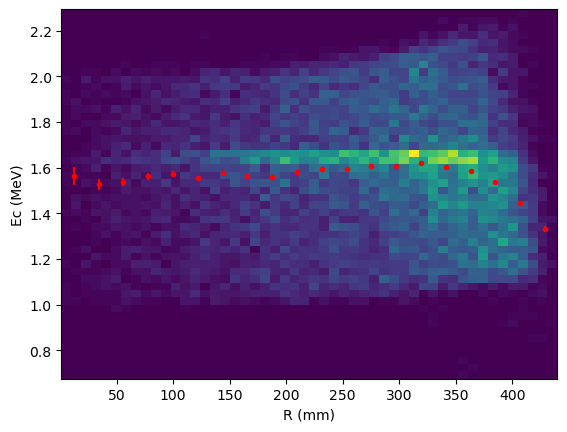

In [66]:
plot_profile(final_reco_summ, 'rad', 'total_energy', plotbins = 50, plotrange=(None, None), axlabel = ['R (mm)', 'Ec (MeV)'])

### Try applying a fiducial cut

In [67]:
rcut = 350
zmin, zmax = 500, 800
final_reco_summ_fid = final_reco_summ[(final_reco_summ.Z_bary > zmin) & (final_reco_summ.Z_bary < zmax) & (final_reco_summ.rad < rcut)]

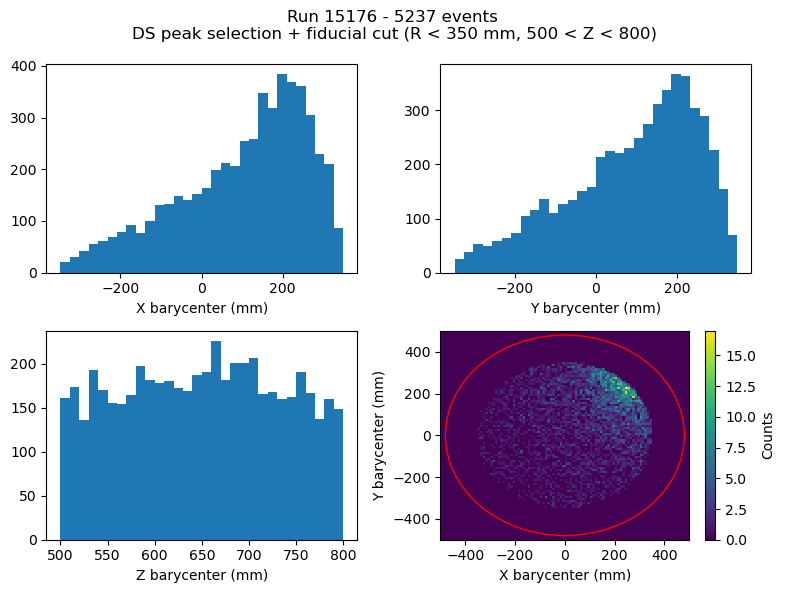

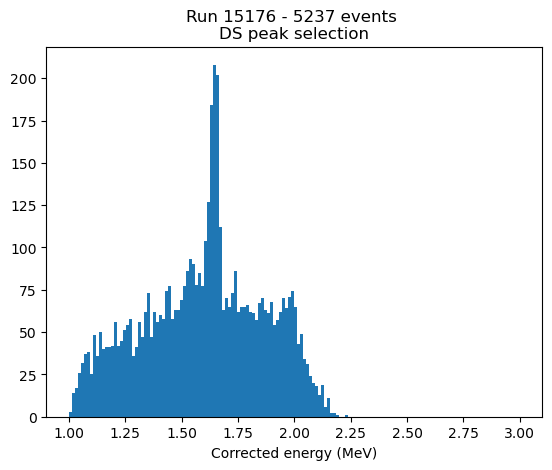

In [68]:
plot_coord_info (final_reco_summ_fid, run_number, c = ['X_bary', 'Y_bary', 'Z_bary'], title = 'DS peak selection + fiducial cut (R < {} mm, {} < Z < {})'.format(rcut, zmin, zmax), xlabels = ['X barycenter (mm)', 'Y barycenter (mm)', 'Z barycenter (mm)'], nbins = (30, 30, 30, (100, 100)))
plt.show()
plot_generic_hist(final_reco_summ_fid, 'total_energy', run_number, nbins = 150, range = (1, 3), xlabel = 'Corrected energy (MeV)', title = 'DS peak selection')
plt.show()

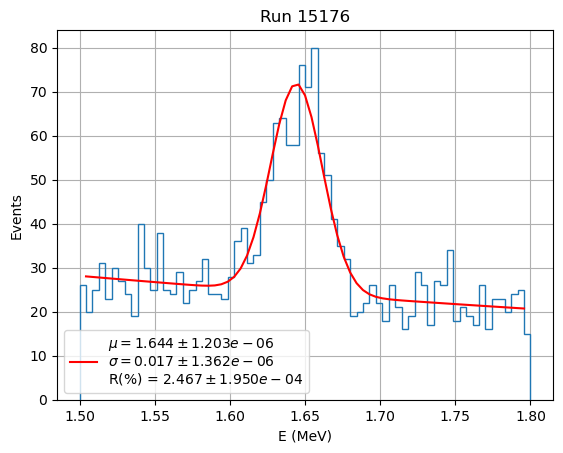

In [69]:
rang = (1.5, 1.8)
initial_params = [250, 1.65, 0.02, 1, 7]
bounds = ([0, 0, 0, -np.inf, 0], [np.inf, np.inf, np.inf, np.inf, np.inf])

r = fit_and_plot_peaks_resolution(final_reco_summ_fid.total_energy, peak_fit, 70, rang, rang, initial_params, bounds, 'Run {}'.format(run_number), density = False)

In [70]:
r

(array([4.75753770e+01, 1.64432821e+00, 1.72246593e-02, 1.32995069e+02,
        9.66102992e-01]),
 2.4667200019059874)

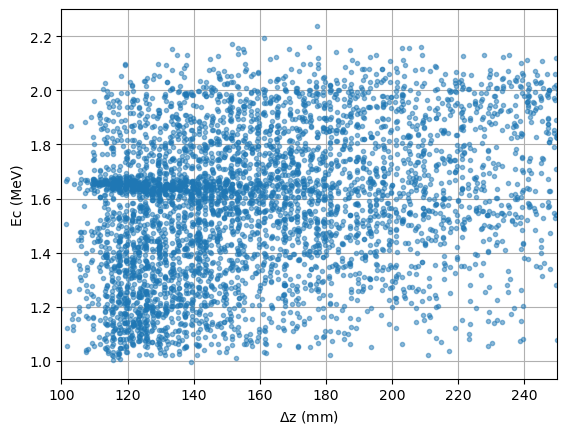

In [53]:
plt.plot(final_reco_summ_fid.dZ, final_reco_summ_fid.total_energy, '.', alpha = 0.5)
plt.xlim((100, 250))
# plt.ylim((1.4, 1.9))
plt.xlabel(r'$\Delta$z (mm)')
plt.ylabel('Ec (MeV)')
plt.grid()

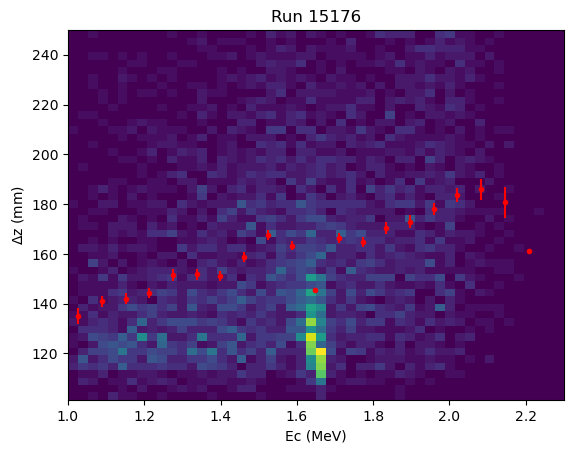

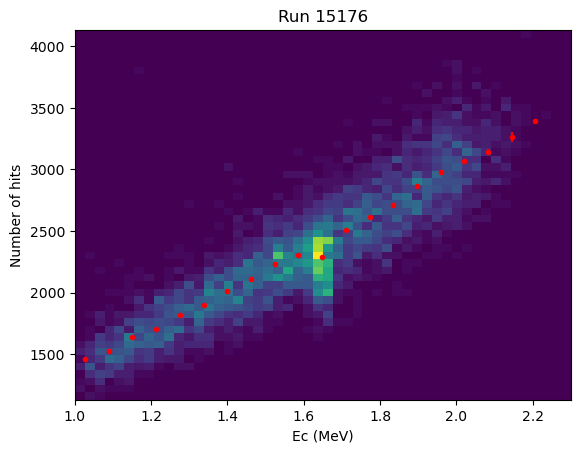

In [54]:
dz_mask = (final_reco_summ_fid.dZ > 100) & (final_reco_summ_fid.dZ < 250) 

plot_profile(final_reco_summ_fid[dz_mask], 'total_energy', 'dZ', plotbins = 50,plotrange=((1, 2.3), None), axlabel = ['Ec (MeV)', '$\Delta$z (mm)'])
plt.title('Run {}'.format(run_number))
plt.show()
plot_profile(final_reco_summ_fid, 'total_energy', 'num_hits',  plotbins = 50,plotrange=((1, 2.3), None), axlabel = ['Ec (MeV)', 'Number of hits'])
plt.title('Run {}'.format(run_number))
plt.show()

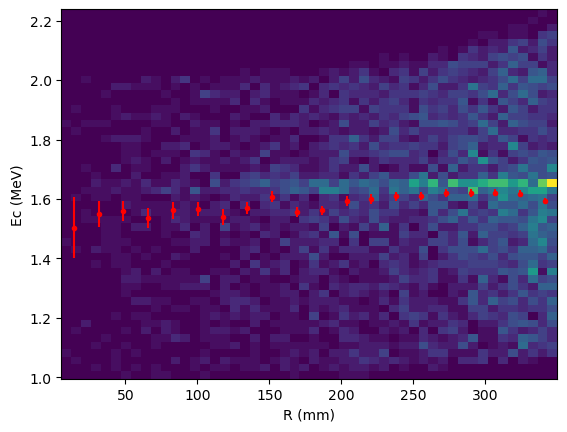

: 

In [ ]:
plot_profile(final_reco_summ_fid, 'rad', 'total_energy', plotbins = 50, plotrange=(None, None), axlabel = ['R (mm)', 'Ec (MeV)'])

### Checking hits

In [ ]:
# recohits = 

In [57]:
ds_reco = recohits[np.isin(list(recohits.event), E_corr_hand[(E_corr_hand > 1.5) & (E_corr_hand < 1.8)].index)]

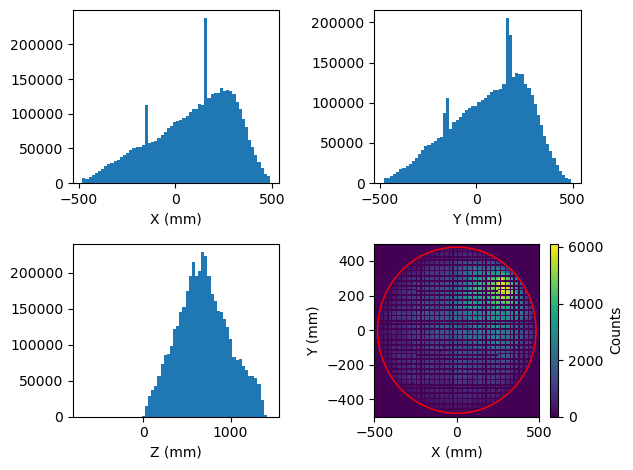

In [58]:
plt.subplot(2, 2, 1)
plt.hist(ds_reco.X, 60)
plt.xlabel('X (mm)')
plt.subplot(2, 2, 2)
plt.hist(ds_reco.Y, 60)
plt.xlabel('Y (mm)')
plt.subplot(2, 2, 3)
plt.hist(ds_reco.Z, 60)
plt.xlabel('Z (mm)')
plt.subplot(2, 2, 4)
hist = plt.hist2d(ds_reco.X, ds_reco.Y, bins=100, range = ((-500, 500), (-500, 500)), cmap='viridis')
plt.colorbar(hist[3], label='Counts')
plt.gca().add_patch(plt.Circle((0, 0), 480, color='r', fill=False, linewidth=1)) 
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.tight_layout()